## Introduction

In this project, we will be exploring binary classification and regression modeling using decision trees with the `Indian Graduate Admissions` dataset provided by `Kaggle`

## Dataset

This dataset primarily contains features that are used in determining admission to graduate degree programs, with the complete list of features summarized below:

- `GRE Scores` (Out of 350)
- `TOEFL Scores` (Out of 120)
- `University Rating` (Out of 5)
- `Statement of Purpose and Letter of Recommendation Strength` (Out of 5)
- `Undergraduate GPA` (Out of 10)
- `Research Experience` (Binary)
- `Chance of Admit` (Ranging from 0 to 1)

In [ ]:
# Installing necessary packages and modules into virtual environment
%pip install pandas
%pip install numpy
%pip install matplotlib
%pip install seaborn
%pip install scikit-learn

In [2]:
# Importing the necessary packages and modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import DecisionTreeRegressor

%matplotlib inline

## Decision Trees for Classification

The first thing that we need to do before anything else, is load our `Admission_Predict` csv file into a Pandas DataFrame.

In addition to this, we will also clean up the column names a little bit.

In [3]:
# Creating a Pandas DataFrame
df = pd.read_csv("Admission_Predict.csv")

# Cleaning column names
df.columns = df.columns.str.strip().str.replace(' ','_').str.lower()

The next thing that we will do is we will create a binary class from the `chance_of_admit` columnn (1 = admission likely, 0 = admission unlikely).

For this instance, we will consider a value greater than 0.8 (80%) as likely to be admitted.

The remaining columns in our dataset will be used as predictor variables.

In [4]:
# Defining our predictors and binary class
X = df.loc[:,'gre_score':'research']
y = df['chance_of_admit']>=.8

The next step that we will take is we will use the `sklearn` `tree` module to create, train, predict, and visualize a decision tree classifier.

This is relatively the same as using any other kind of `sklearn` model.

In [5]:
# Creating our Decision Tree Classifier
x_train, x_test, y_train, y_test = train_test_split(X,y, random_state=0, 
                                                    test_size=0.2)
dt = DecisionTreeClassifier(max_depth=2, ccp_alpha=0.01, criterion='gini')
dt.fit(x_train, y_train)
y_pred = dt.predict(x_test)

# Printing Score and Accuracy Score
print(dt.score(x_test, y_test))
print(accuracy_score(y_test, y_pred))

0.925
0.925


The next thing that we would like to do is to visualize our decision tree.

In this project, we will be using the `export_text` method from the `sklearn` `tree` module.

Note that there are other ways to create a visualization of a decision tree, but this is the method that will be used for this project.

|--- cgpa <= 8.85
|   |--- class: False
|--- cgpa >  8.85
|   |--- gre_score <= 313.50
|   |   |--- class: False
|   |--- gre_score >  313.50
|   |   |--- class: True



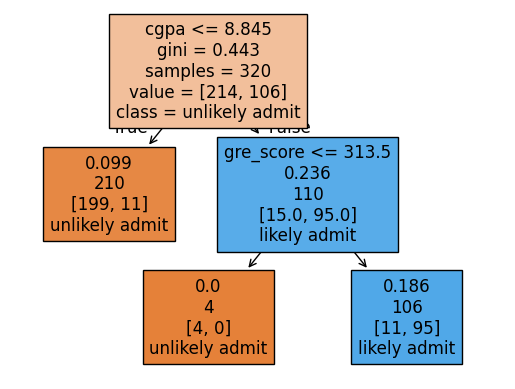

In [6]:
# Plotting and Visualizing our Tree
tree.plot_tree(dt, feature_names = x_train.columns, 
               max_depth=3, class_names = ['unlikely admit', 'likely admit'], 
               label='root', filled=True)

# Printing the visual
print(tree.export_text(dt, feature_names = X.columns.tolist()))

A couple things to note in the above results:

1. For any classification task, the default split criteria is the `Gini Imputiry` - which essentially gives us some insight into how impure our groupings are.

2. At the root node, the first split is chosen as the split that will maximize the information gain, which is also what decreases the Gini Impurity the most, leading to a more pure grouping arrangement.

3. Also, we want to begin to investigate how the initial split of `cgpa<=8.85` is actually determined. Here, `cgpa` is a continuous variable which can make this a bit more complicated, as the split technically could occur at any value of `cgpa`.

To verify initially that this initial split does maximize information gain and minimizes gini impurity, we will use the functions `gini` and `info_gain`.

Note that we are manually defining these functions.

In [7]:
# Defining and utilizing gini function
def gini(data):
    """Calculate the Gini Impurity Score"""
    data = pd.Series(data)
    return 1 - sum(data.value_counts(normalize=True)**2)

gi = gini(y_train)
print(f'Gini impurity at root: {round(gi,3)}')

Gini impurity at root: 0.443


Our output here is just clarifying our initial results provided by the classifier.

Now, we are going to actually verify how the initial split was determined - as in - where did the value of `8.845` actually come from.

We will start by defining our previously mentioned `info_gain` function.

In [8]:
# Defining info_gain function
def info_gain(left, right, current_impurity):
    """Information Gain associated with creating a node/split data.
    Input: left, right are data in left branch, right branch, respectively
    current_impurity is the data impurity before splitting into left, right 
    branches"""

    # weight for total gini score of the left branch
    w = float(len(left)) / (len(left) + len(right))
    return current_impurity - w * gini(left) - (1 - w) * gini(right)

Now that the function is defined, what we want to do next is call the `info_gain()` function over all of the values of `cgpa` to determine the information gain when split on each and every value.

How we do this is by defining a list (table), sorting it, and then if all goes as intended, the first value in the outputted table should be the value of `cgpa<=8.845`.

In [9]:
# Defining table, sorting, calling info_gain over all values
info_gain_list = []
for i in x_train.cgpa.unique():
    left = y_train[x_train.cgpa<=i]
    right = y_train[x_train.cgpa>i]
    info_gain_list.append([i, info_gain(left, right, gi)])

ig_table = pd.DataFrame(info_gain_list, columns=['split_value', 
'info_gain']).sort_values('info_gain', ascending=False)
ig_table.head(10)

,split_value,info_gain
10,8.84,0.296932
124,8.85,0.291464
139,8.88,0.290704
18,8.90,0.290054
98,8.83,0.287810
110,8.87,0.286050
152,8.94,0.284714
57,8.96,0.284210
96,8.80,0.283371
21,9.00,0.283364


As we can see, everything worked as expected!

Now, let's plot a visual just to get a bit more of an idea of how this looks.

Text(0, 0.5, 'info_gain')

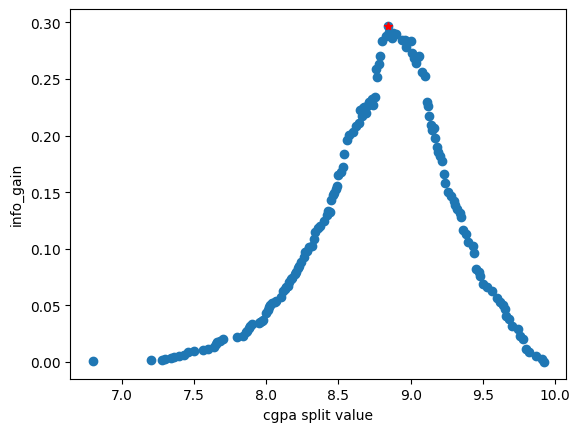

In [10]:
# Creating and displaying plot
plt.plot(ig_table['split_value'], ig_table['info_gain'], 'o')
plt.plot(ig_table['split_value'].iloc[0], ig_table['info_gain'].iloc[0], 'r*')
plt.xlabel('cgpa split value')
plt.ylabel('info_gain')

## Regression

For our regression analysis, we will be using the `chance_of_admit` feature.

Reminder that this is a floating point value between 0 and 1.

In [11]:
# Defining our features
X = df.loc[:, 'gre_score':'research']
y = df['chance_of_admit']

Now, we need to fit and predict our model.

This is essentially identical to the classifier we did prior, except for the split criterion.

When running a regression as opposed to a classifier, we must use the `Mean Squared Error` or `MSE`.

Let's get into it.

In [12]:
# Creating, Fitting, and Predicting our regression model
x_train, x_test, y_train, y_test = train_test_split(X,y, random_state=0, 
                                                    test_size=0.2)
dt = DecisionTreeRegressor(max_depth=3, ccp_alpha=0.001)
dt.fit(x_train, y_train)
y_pred = dt.predict(x_test)
print(dt.score(x_test, y_test))

0.5230242793515554


Next, we can visualize our tree much like we did before with our classifier.

Note however that the splitting criteria here is MSE and the value is `chance_of_admit`.

[Text(0.5, 0.8333333333333334, 'cgpa <= 8.845\nsquared_error = 0.021\nsamples = 320\nvalue = 0.727'),
 Text(0.25, 0.5, 'cgpa <= 8.035\nsquared_error = 0.012\nsamples = 210\nvalue = 0.651'),
 Text(0.375, 0.6666666666666667, 'True  '),
 Text(0.125, 0.16666666666666666, 'squared_error = 0.009\nsamples = 60\nvalue = 0.533'),
 Text(0.375, 0.16666666666666666, 'squared_error = 0.006\nsamples = 150\nvalue = 0.698'),
 Text(0.75, 0.5, 'cgpa <= 9.195\nsquared_error = 0.005\nsamples = 110\nvalue = 0.872'),
 Text(0.625, 0.6666666666666667, '  False'),
 Text(0.625, 0.16666666666666666, 'squared_error = 0.003\nsamples = 55\nvalue = 0.816'),
 Text(0.875, 0.16666666666666666, 'squared_error = 0.001\nsamples = 55\nvalue = 0.928')]

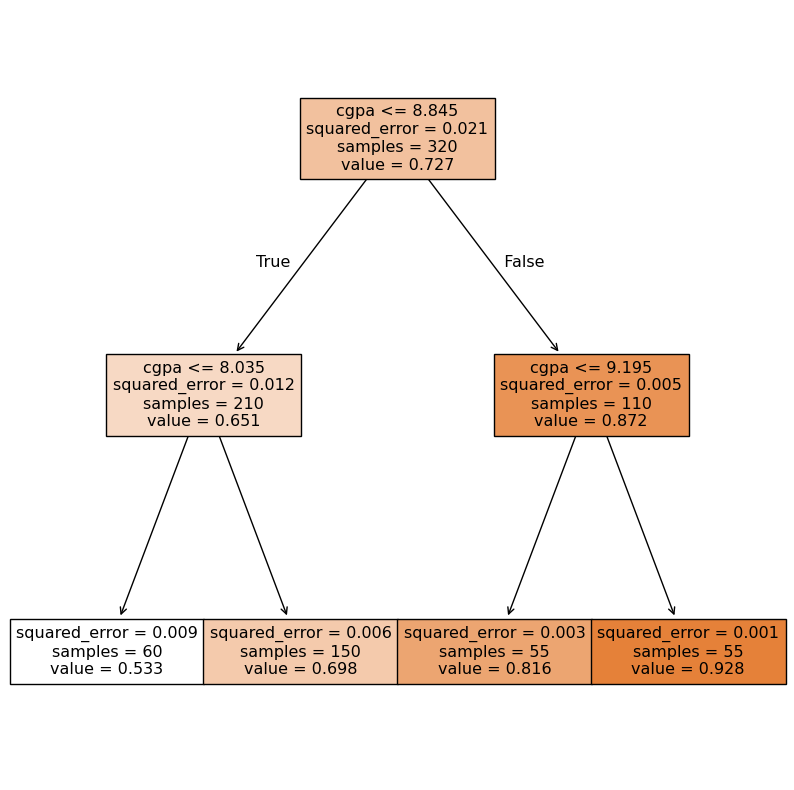

In [13]:
# Displaying regression tree
plt.figure(figsize=(10,10))
tree.plot_tree(dt, feature_names = x_train.columns, 
               max_depth=2, filled=True)

Now, unlike before with the classifier, where we split the tree into classes at each level, the value is now the average of all samples that fit the logical criteria.

Now to determine the split, for each value of cgpa, the information gain, or decrease in the MSE after the split, is calculated and the values are then sorted.

Here, we will see that once again, the best split is `cgpa<=8.84`.

Now, we will essentially repeat the same steps as we did in the classifier portion, changing `info_gain` to `mse_gain`.

In [14]:
# Defining mse, mse_gain
def mse(data):
    """Calculate the MSE of a dataset"""
    return np.mean((data - data.mean())**2)

def mse_gain(left, right, current_mse):
    """Information Gain (MSE) associated with creating a node/split data based on MSE.
    Input: left, right are data in left branch, right branch, respectively
    current_impurity is the data impurity before splitting into left, right 
    branches"""

    # weight for gini score of left branch
    w = float(len(left)) / (len(left) + len(right))
    return current_mse - w * mse(left) - (1 - w) * mse(right)

m = mse(y_train)
print(f'MSE at root: {round(m,3)}')

# Defining table, sorting, calling mse_gain over all values
mse_gain_list = []
for i in x_train.cgpa.unique():
    left = y_train[x_train.cgpa<=i]
    right = y_train[x_train.cgpa>i]
    mse_gain_list.append([i, mse_gain(left, right, m)])

mse_table = pd.DataFrame(mse_gain_list, columns=['split_value', 
'info_gain']).sort_values('info_gain', ascending=False)
print(mse_table.head(10))

MSE at root: 0.021
     split_value  info_gain
10          8.84   0.011065
96          8.80   0.011037
98          8.83   0.011023
124         8.85   0.010985
125         8.73   0.010939
110         8.87   0.010932
139         8.88   0.010895
1           8.70   0.010894
17          8.76   0.010858
140         8.74   0.010850


Now, once again, we should plot our results just to get more of a visual.

Text(0, 0.5, 'info gain')

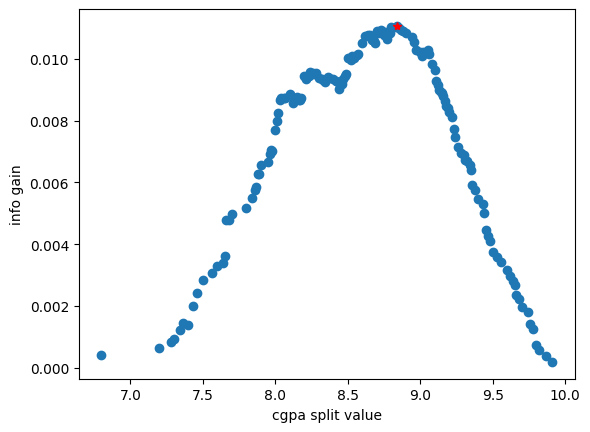

In [15]:
# Plotting results
plt.plot(mse_table['split_value'], mse_table['info_gain'], 'o')
plt.plot(mse_table['split_value'].iloc[0], 
         mse_table['info_gain'].iloc[0], 'r*')
plt.xlabel('cgpa split value')
plt.ylabel('info gain')

Once again, this process will continue until there is no increase in information gain by splitting.

Evaluation occurs in essentially the same way. A sample of data will work its way through the tree until it reaches a leaf node and is then assigned the average value of the samples in the leaf.

Depending on the depth of the tree, the predicted values can be limited.

In our example, only four unique predicted values are possible, which we will verify below.

Note that this is something to keep in mind. When using a decision tree regressor as opposed to a liner/logistic regressor, not all output values may be possible.

In [16]:
# Printing possible output values
np.unique(dt.predict(x_train))

array([0.53283333, 0.6976    , 0.81618182, 0.92781818])